In [1]:
import os

import tifffile
import numpy as np
import cv2
%matplotlib inline
from matplotlib import pyplot as plt
from math import sqrt, ceil, hypot, degrees, atan

from scipy.ndimage.morphology import binary_fill_holes
from scipy import interpolate
from skimage import feature
from skimage.filters import threshold_otsu, gaussian
from skimage.transform import rotate, SimilarityTransform
from skimage.morphology import disk, erosion, remove_small_holes, binary_opening, remove_small_objects

from skimage.io import imsave
from readlif.reader import LifFile

In [2]:
src_filepath = '/Users/christina.bukas/Documents/AI_projects/datasets/220902_No_contraction_curare'
dst_filepath = '/Users/christina.bukas/Documents/AI_projects/datasets/dev_220902_No_contraction_curare'
files = [file for file in os.listdir(src_filepath) if file.endswith('.lif')]
print('Dataset includes ', len(files), ' videos')

Dataset includes  12  videos


## Convert lif files to tifs

In [3]:
for file in files:
    img = LifFile(os.path.join(src_filepath, file))
    img_0 = img.get_image(0)
    img_list   = [i for i in img_0.get_iter_t(c=0, z=0)]
    img_array = np.stack(img_list)
    tif_name = file.split('.')[0]+'.tif'
    imsave(os.path.join(dst_filepath, tif_name), img_array)

# Useful functions for border extraction

In [5]:
def remove_border_points(border_points):
    '''Remove the white pixels on border of image'''
    border_x = list(border_points[0])
    border_y = list(border_points[1])
    i = 0
    remove_ids = []
    for x, y in zip(border_x, border_y):
        if x<2 or x>252 or y<5 or y>252: remove_ids.append(i)
        i+=1
    for i in reversed(remove_ids):
        border_x.pop(i)
        border_y.pop(i)
    return (np.array(border_x), np.array(border_y))

def extract_border(img_slice, sigma_smooth=2, sigma_edge=3):
    '''
    Extract the border from a single frame, by following:
    1. Threshold image using Otsu thresholding
    2. Apply morphological opening and fill any holes in the binary image
    3. Compute edges using the Canny edge Detection algorithm
    4. Remove white pixels from border of image
    6. Return border coordinates and binary image
    '''
    img_smooth = gaussian(img_slice, sigma_smooth)
    thresh = threshold_otsu(img_smooth)
    image_thresh = img_smooth > thresh
    image_thresh = binary_opening(image_thresh, disk(4))
    image_thresh = remove_small_objects(image_thresh, min_size=400)
    
    edges = feature.canny(image_thresh, sigma_edge)
    x,y = remove_border_points((np.where(edges)))

    return (x,y), image_thresh 

def sort_border(x,y):
    ''' Sort border pixels such that the signal coordinates are continuous'''
    sorted_x = x[np.argsort(x)]
    sorted_y = y[np.argsort(y)]
    max_dist_x = sorted_x[-1] - sorted_x[0]
    max_dist_y = sorted_y[-1] - sorted_y[0]
    if max_dist_x > max_dist_y: point0 = np.where(x==sorted_x[0])[0][0]
    else: point0 = np.where(y==sorted_y[0])[0][0]
    sorted_ids = np.argsort((x-x[point0])**2+(y-y[point0])**2) # x+y
    x = x[sorted_ids]
    y = y[sorted_ids]
    return (x,y)

def get_border_angle(x , y):
    ''' Compute the angle of the border considering it as a line from first to last point'''
    xl = x[-1] - x[0]
    yl = y[-1] - y[0]
    theta = degrees(atan(xl/yl))
    return theta


## Work on signal extraction from border extraction at every frame

For this approach we are assuming there is no drift of the organoids, or else, that the border area remains the same throughout the video. After examining the videos we see that this is not the case for:

 - 220516_No contraction videos.lif - O1450_2 curare II.tif -> **strong drift**

 - Strong contraction.lif - O1319_1a.tif -> **slight drift**
 
 - Strong contraction.lif - O1468_1b.tif -> **strong drift or strong contraction??**

In [27]:
filepath = dst_filepath
files = [file for file in os.listdir(filepath) if file.endswith('.tif')]

subsample = 1
wait = 1
view = False
save_np = True
subsample_regions = 10
    
for vid_id in range(len(files)):
    
    example_file = files[vid_id]
    print('Working on file: ', example_file)
    vid = tifffile.imread(os.path.join(filepath, example_file))
    
    distances = np.zeros((subsample_regions, vid.shape[0]//subsample))
    border_size = []
    rotated_masks = []
    
    # go once over entire video to get min length of border
    for frame_id in range(vid.shape[0]//subsample): 
        
        # extract border and sort pixels
        (x,y), _ = extract_border(vid[frame_id], sigma_smooth=2, sigma_edge=3)
        x, y = sort_border(x, y)
        
        # Rotate border so that is always parallel to x-axis
        theta = get_border_angle(x , y)
        mask = np.zeros(vid[frame_id].shape, dtype=bool)
        mask[(x,y)] = True #size 256, 256
        mask_r = rotate(mask, theta, resize=True) # shape usually 305,305 but changes
        
        # store rotated image and length of border
        y = np.sort(np.where(mask_r)[1])
        dist_y = y[-1] - y[0]
        border_size.append(dist_y)
        rotated_masks.append(mask_r)
        
    # get minimum border length
    border_size = np.array(border_size)
    #print('Mean:', np.mean(border_size), 'std:', np.std(border_size), 'min: ', np.min(border_size))
    bbox_size = np.min(border_size)
    if bbox_size%2==1: bbox_size-=1
    print('Border rectangle size: ', bbox_size)

    if view: cv2.destroyAllWindows()

    # and go a second time over to extract signals 
    for frame_id in range(vid.shape[0]//subsample):

        mask_r = rotated_masks[frame_id]

        # Pad so we always have a fixed size image
        resize_size = (512 - mask_r.shape[0], 512 - mask_r.shape[1])
        mask_r = np.pad(mask_r, ((resize_size[0]//2+mask_r.shape[0]%2, resize_size[0]//2), (resize_size[1]//2+mask_r.shape[1]%2, resize_size[1]//2)))

        # Translate always relative to middle of image and around median of columns
        if frame_id==0: 
            where_border = np.where(mask_r)
            mean_x = round(np.mean(where_border[0]))
            median_y = round(np.median(where_border[1]))
        # crop edges of border so hopefully we are always including the same border points
        mask_r = mask_r[mean_x-100:mean_x+100, median_y-bbox_size//2:median_y+bbox_size//2]
        
        # get new img size and size of subsampled regions
        new_height, new_width = mask_r.shape
        subsample_area = new_width//subsample_regions
        
        # get the average of coordinates in sub-region along the x-axis and subtract from average if frame0
        for i in range(subsample_regions):
            sub_area = mask_r[:,i*subsample_area:(i+1)*subsample_area]
            x_sub, _ = np.where(sub_area)
            distances[i, frame_id] = np.mean(x_sub)
        
        # Display
        if view:
            frame = cv2.cvtColor((mask_r*255).astype(np.uint8),cv2.COLOR_GRAY2RGB)
            #out.write(frame) # uncomment for video saving
            cv2.namedWindow(example_file) 
            cv2.moveWindow(example_file, 150,150) 
            for i in range(subsample_regions):
                frame = cv2.line(frame, (i*subsample_area, 0), (i*subsample_area, new_height-1), (0, 0, 255), thickness=1) 
                frame = cv2.circle(frame, (round(i*subsample_area+subsample_area//2), round(distances[i, frame_id])), radius=2, color=(0, 255, 0), thickness=-1)

            cv2.imshow(example_file, frame)
            k = cv2.waitKey(wait)
            if k == 27: break
    
    if save_np:
        for i in range(10):
            distances[i, :] -= distances[i,0]
        new_file = example_file+'.npy'
        np.save(new_file, distances)

Working on file:  O1409_1b.tif
Border rectangle size:  282
Working on file:  O2652_2b_curare.tif
Border rectangle size:  294
Working on file:  O2542_1c_curare.tif
Border rectangle size:  330
Working on file:  O2573_1b_curare.tif
Border rectangle size:  270


/Users/christina.bukas/opt/anaconda3/envs/imaging/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3420: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/Users/christina.bukas/opt/anaconda3/envs/imaging/lib/python3.7/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Working on file:  O2652_1b_curare.tif
Border rectangle size:  248
Working on file:  O2542_2b_curare.tif
Border rectangle size:  254
Working on file:  O2652_1a_curare.tif
Border rectangle size:  252
Working on file:  O1498_1a_curare.tif
Border rectangle size:  250
Working on file:  O1450_1b_curare.tif
Border rectangle size:  246
Working on file:  O3199_1_curare.tif
Border rectangle size:  250
Working on file:  P766_1b.tif
Border rectangle size:  292
Working on file:  P918_1b_recovery_curare.tif
Border rectangle size:  248


## Checking that signals were extarcted and stored correclty

File:  O3199_1_curare.tif.npy  with shape:  (10, 3015)
File:  P918_1b_recovery_curare.tif.npy  with shape:  (10, 3114)
File:  O2652_1b_curare.tif.npy  with shape:  (10, 3147)
File:  O2542_2b_curare.tif.npy  with shape:  (10, 3147)
File:  O2652_1a_curare.tif.npy  with shape:  (10, 3147)
File:  O1450_1b_curare.tif.npy  with shape:  (10, 1208)
File:  O1409_1b.tif.npy  with shape:  (10, 1813)
File:  O2652_2b_curare.tif.npy  with shape:  (10, 3147)
File:  P766_1b.tif.npy  with shape:  (10, 3147)
File:  O2573_1b_curare.tif.npy  with shape:  (10, 3147)
File:  O1498_1a_curare.tif.npy  with shape:  (10, 1208)
File:  O2542_1c_curare.tif.npy  with shape:  (10, 3147)


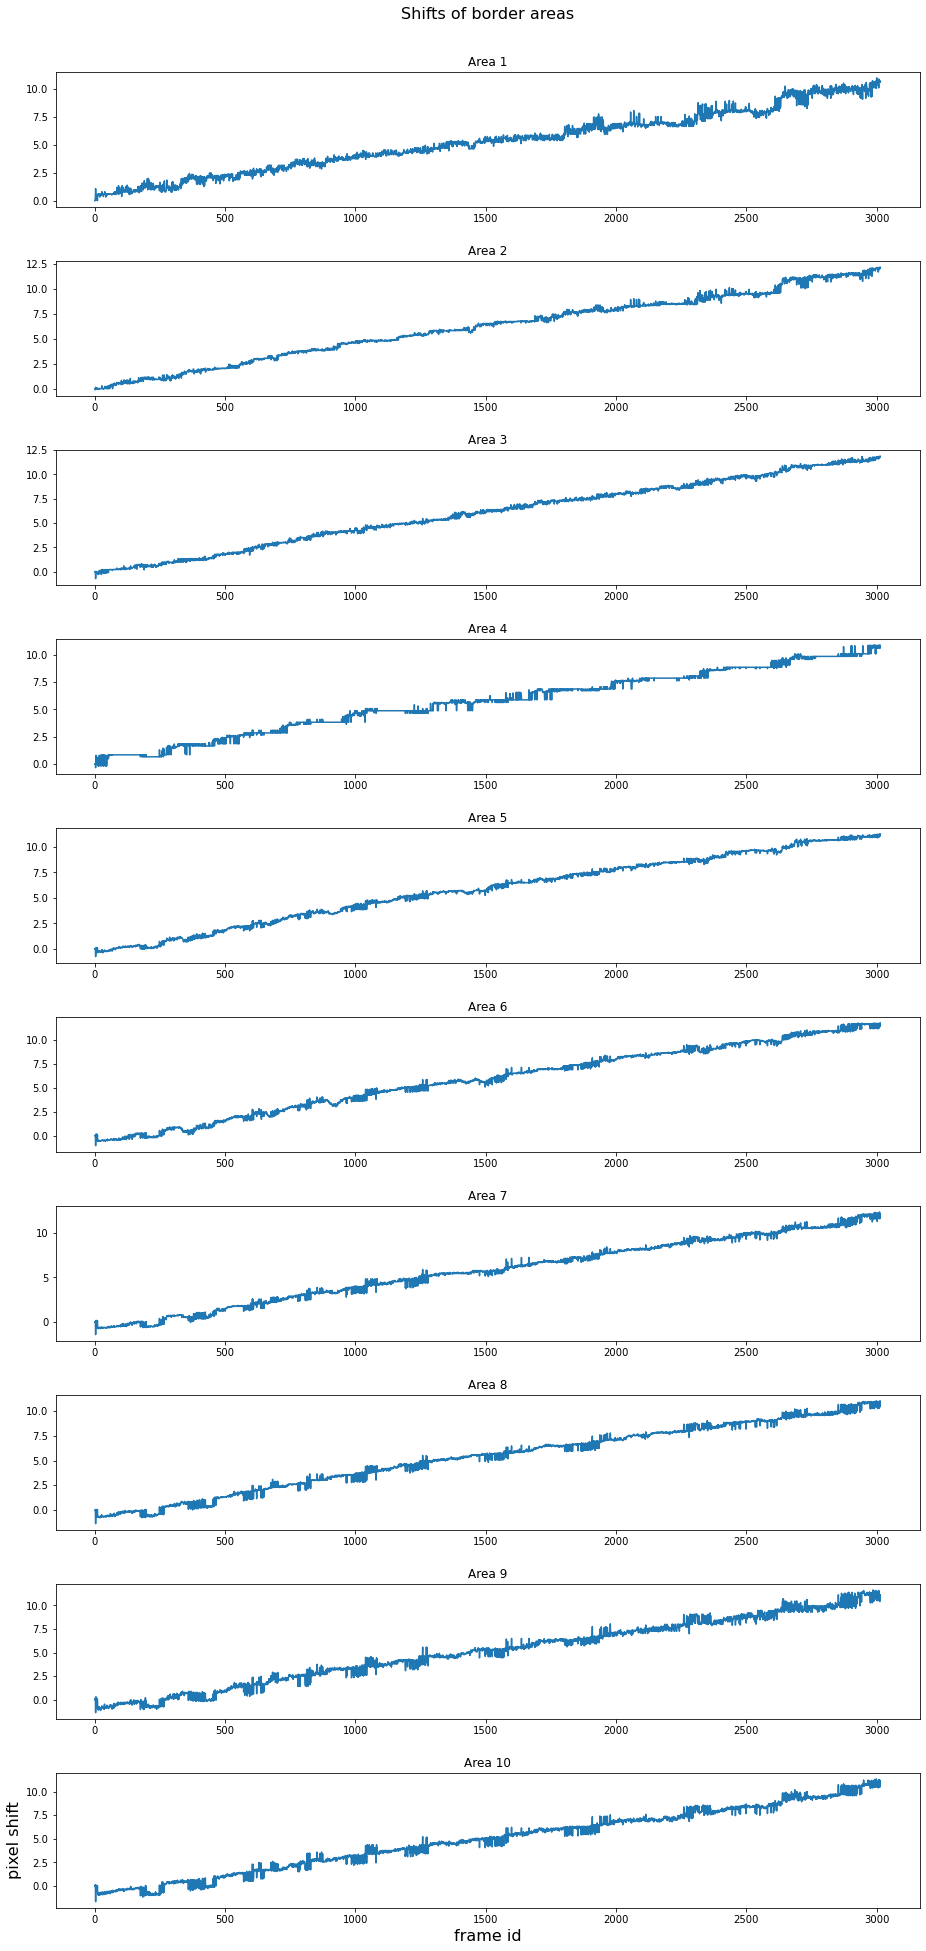

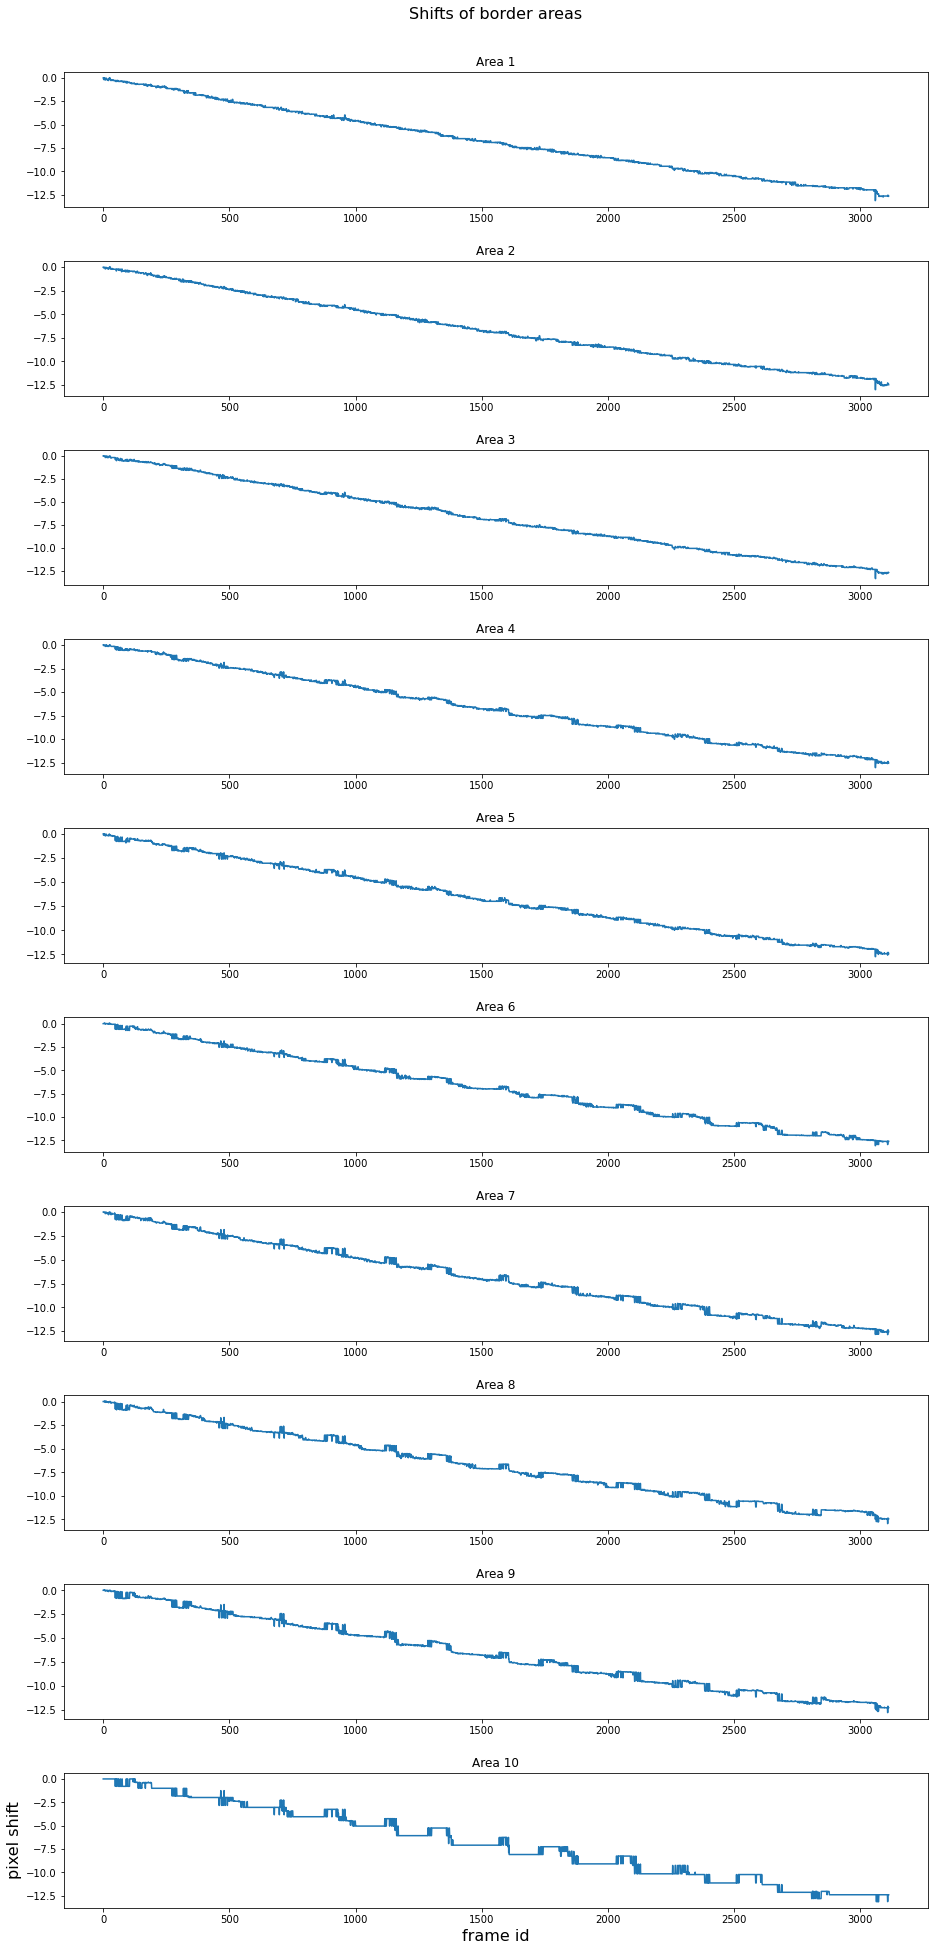

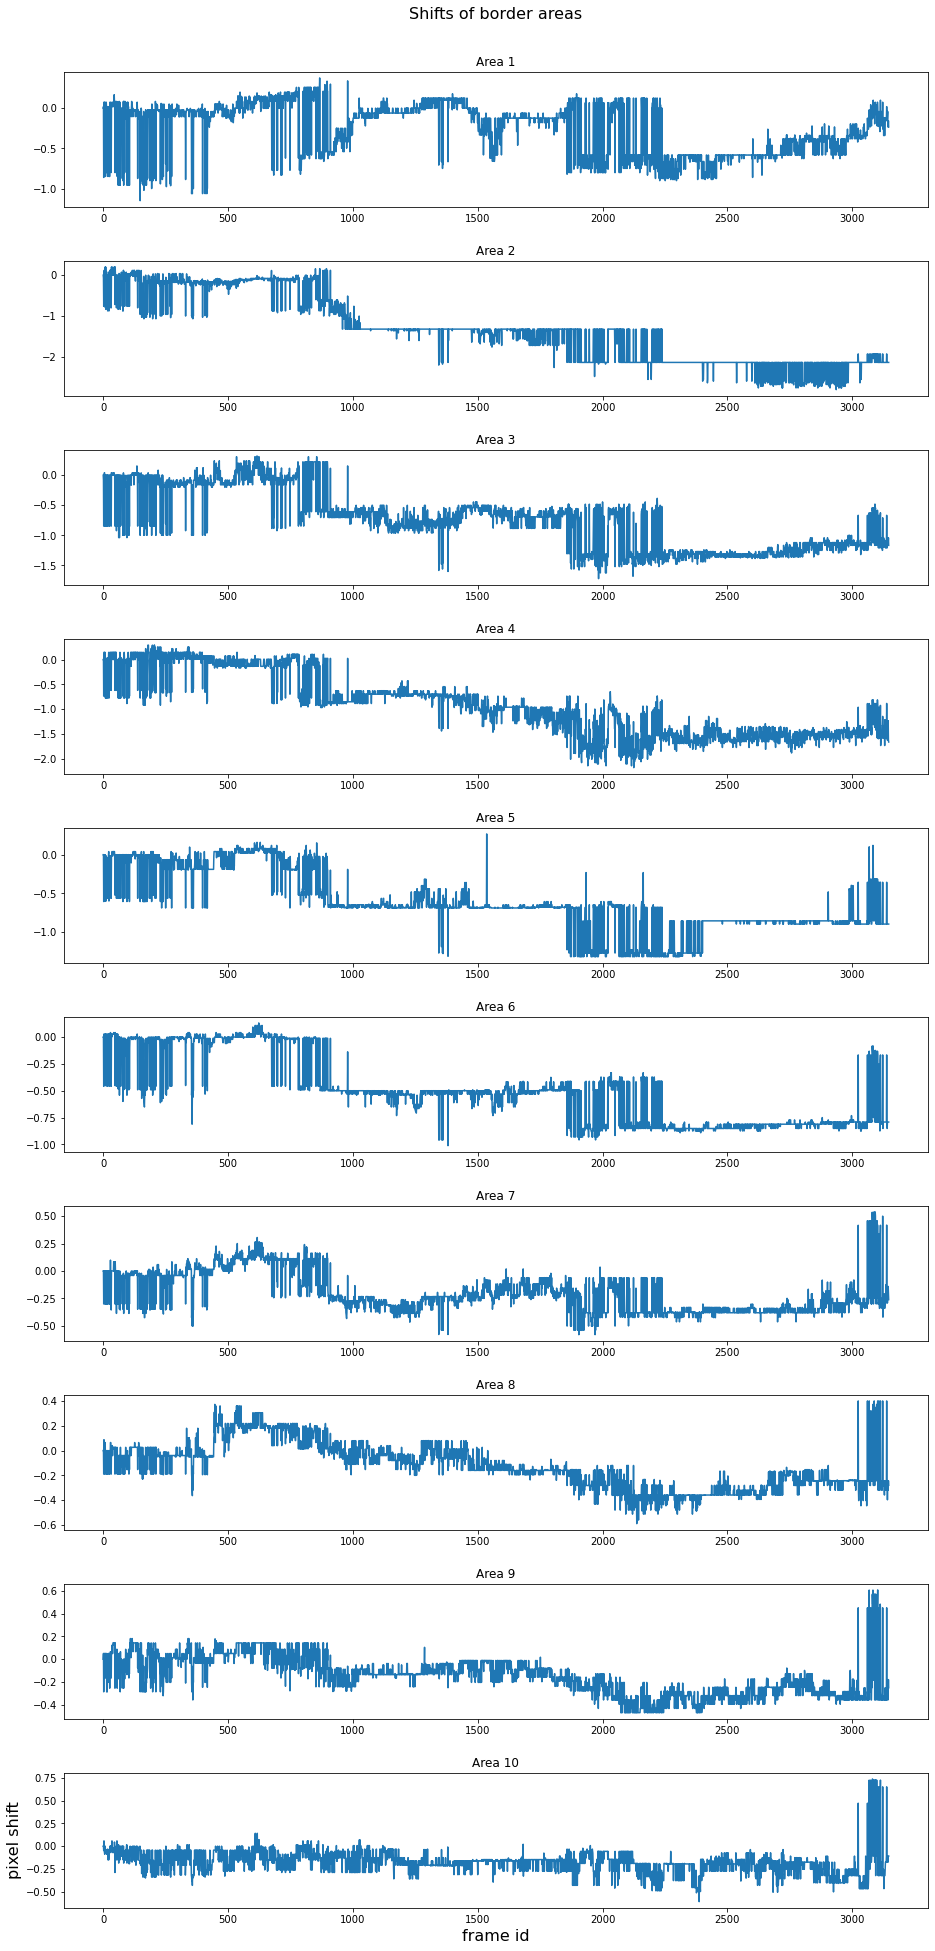

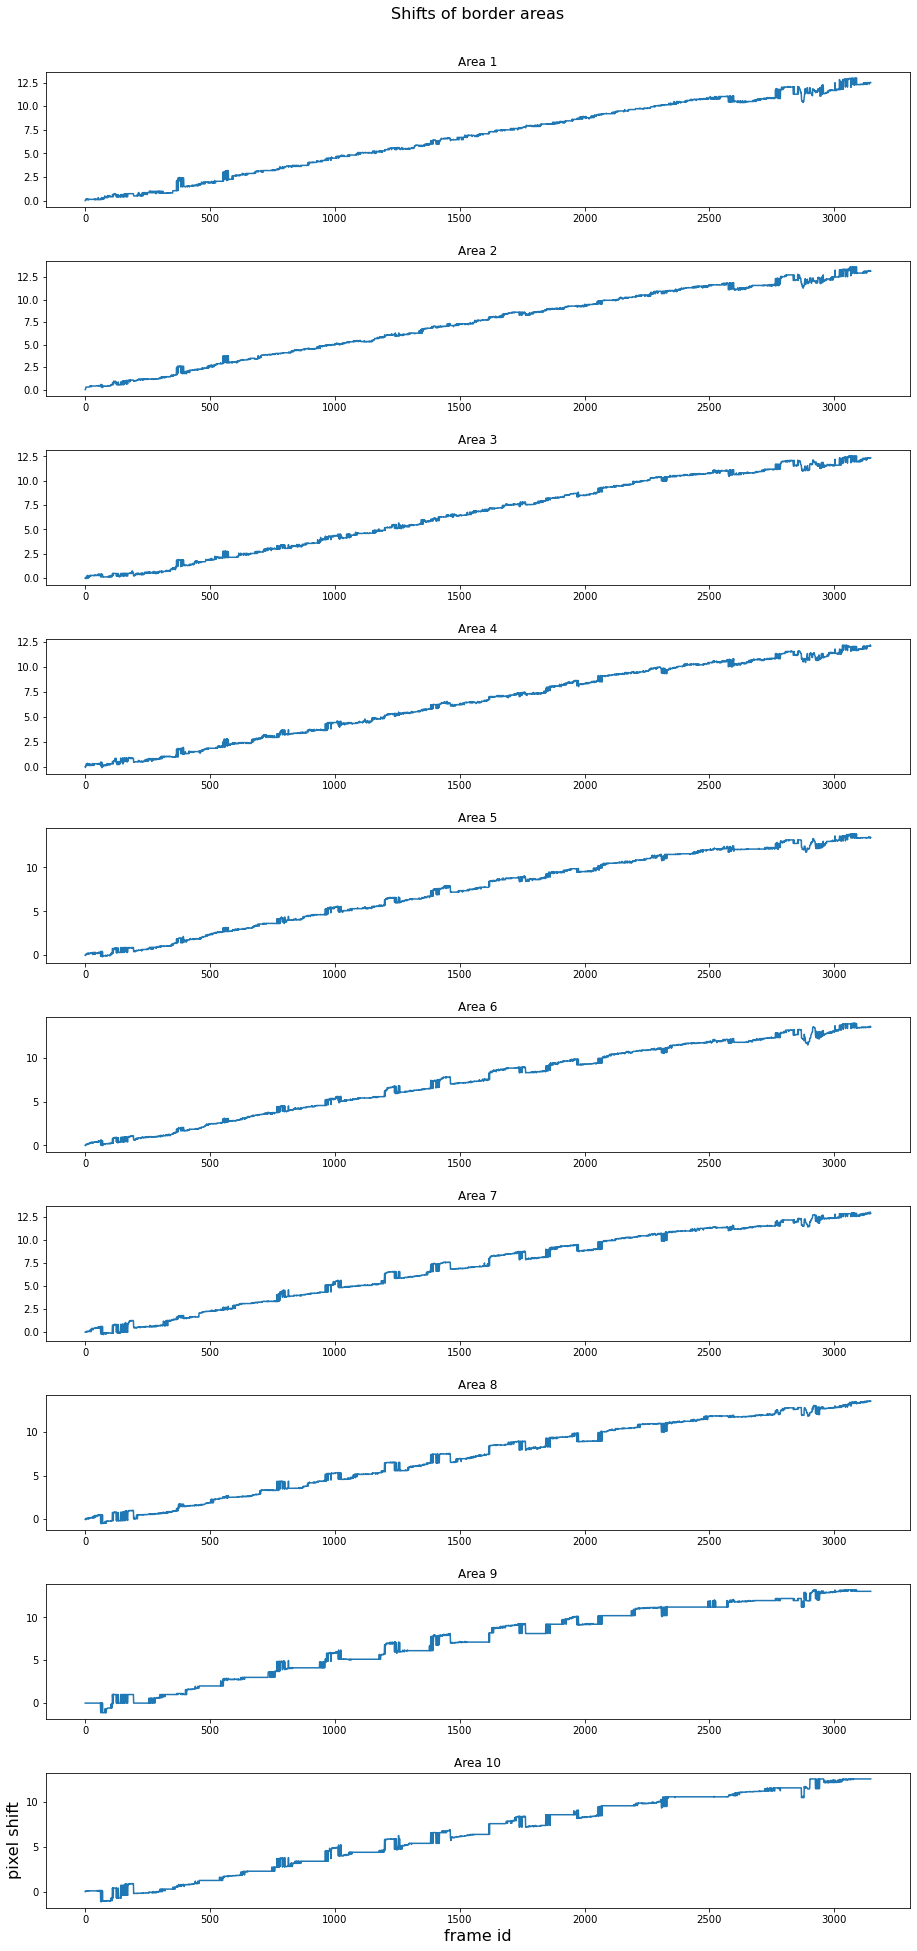

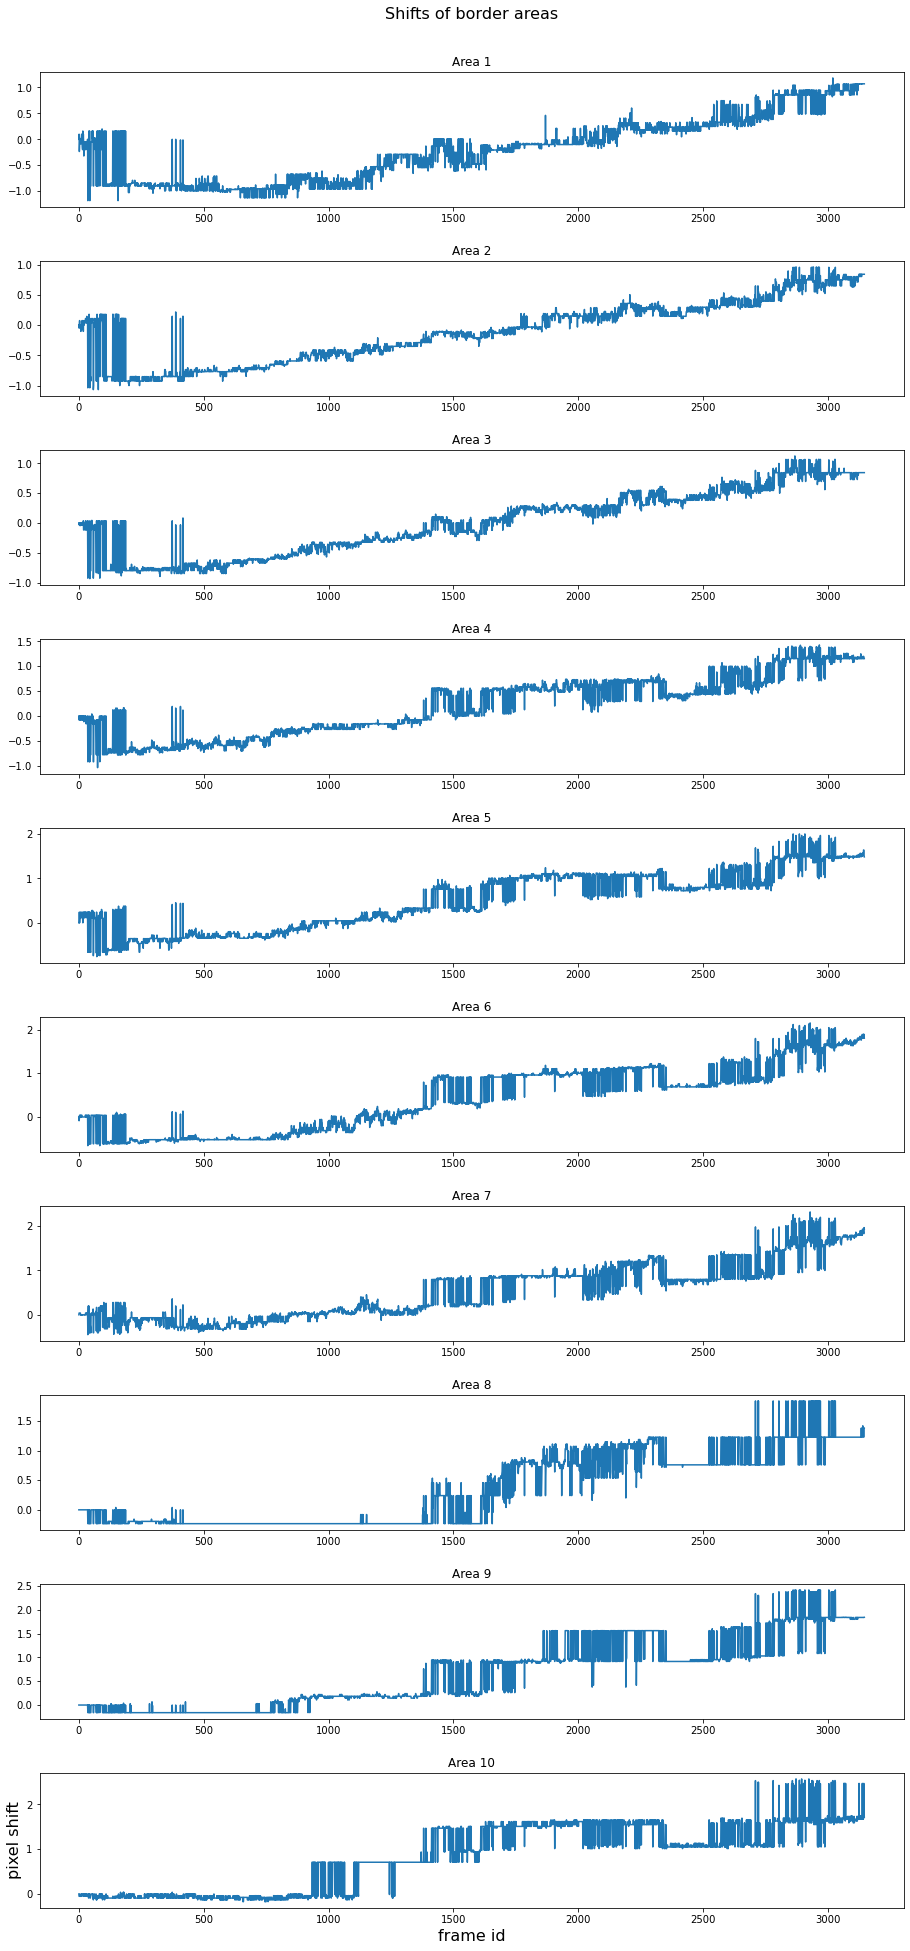

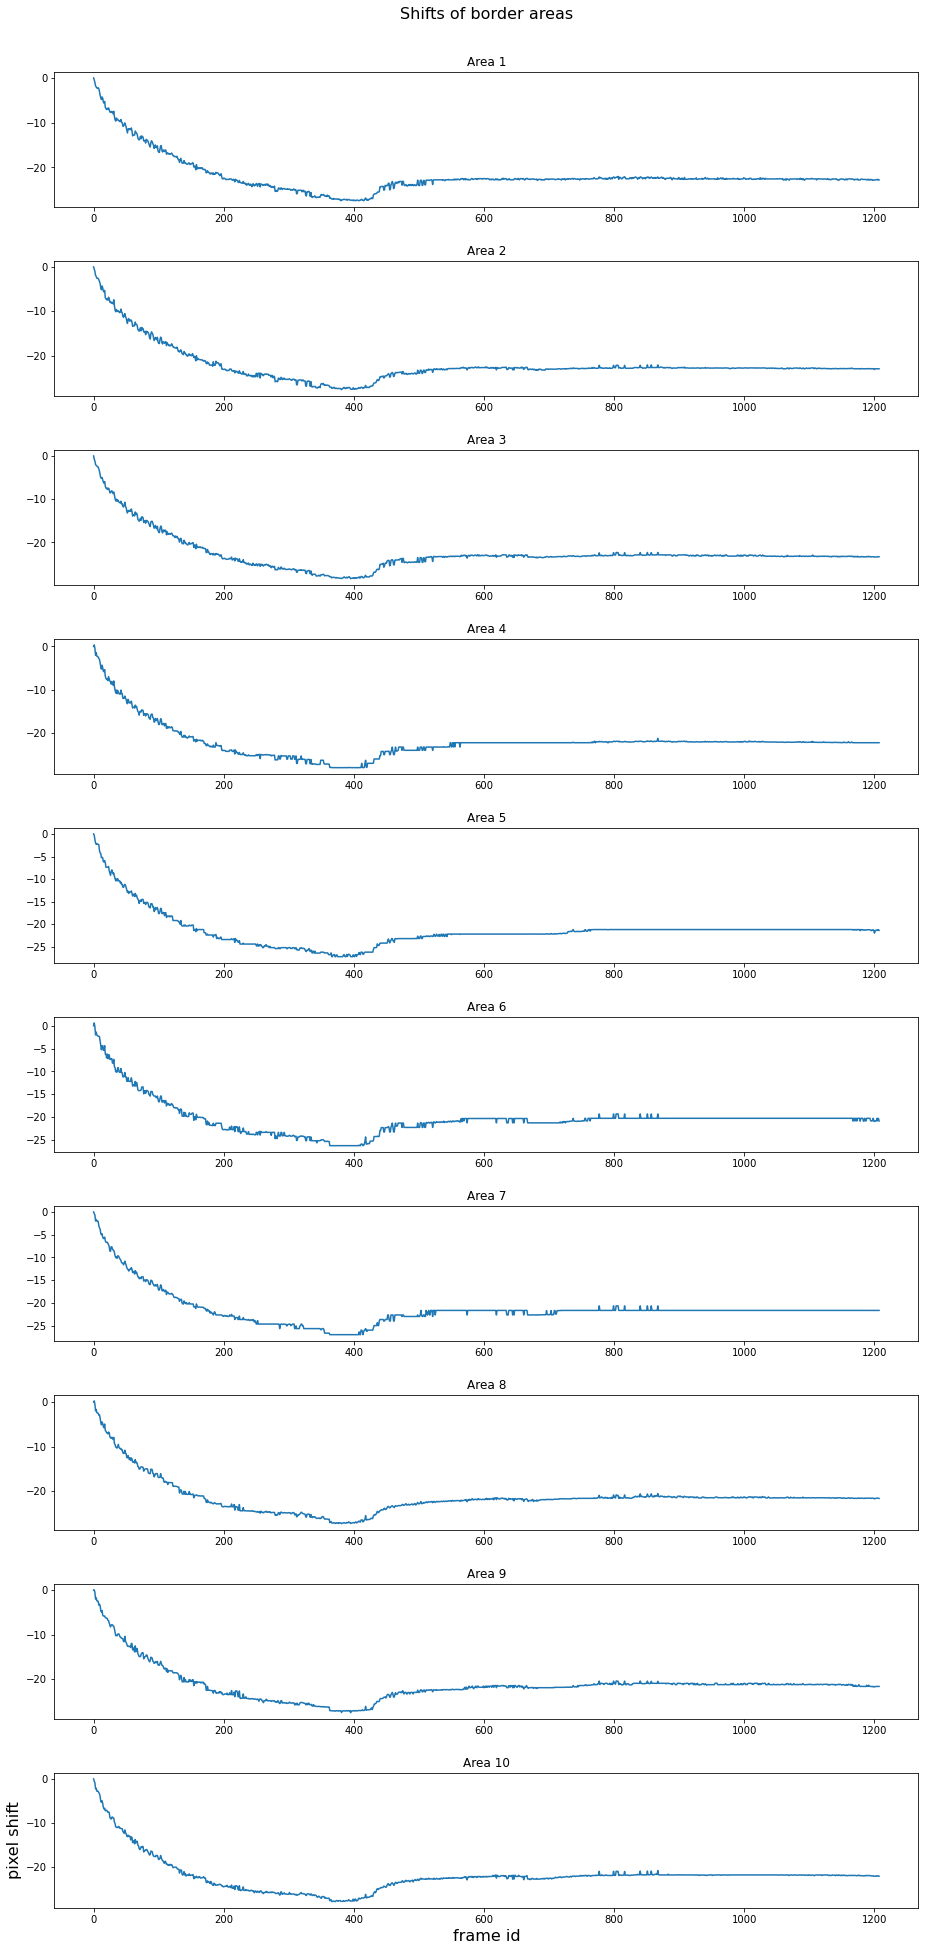

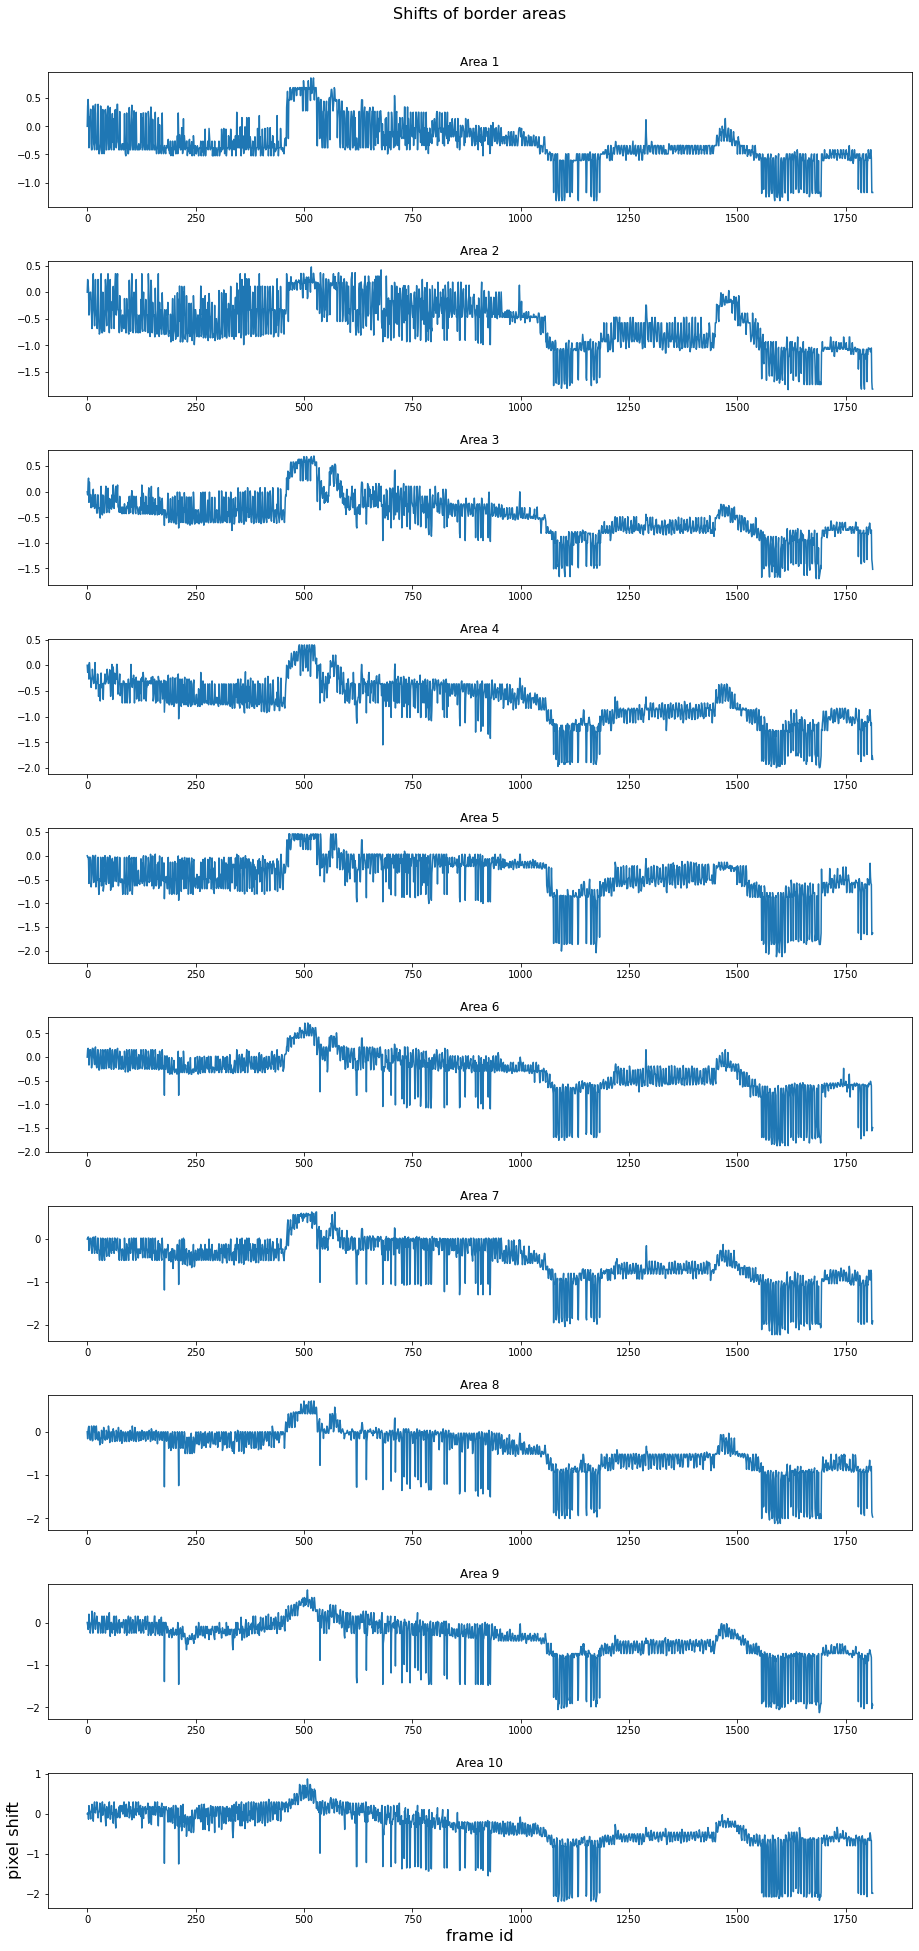

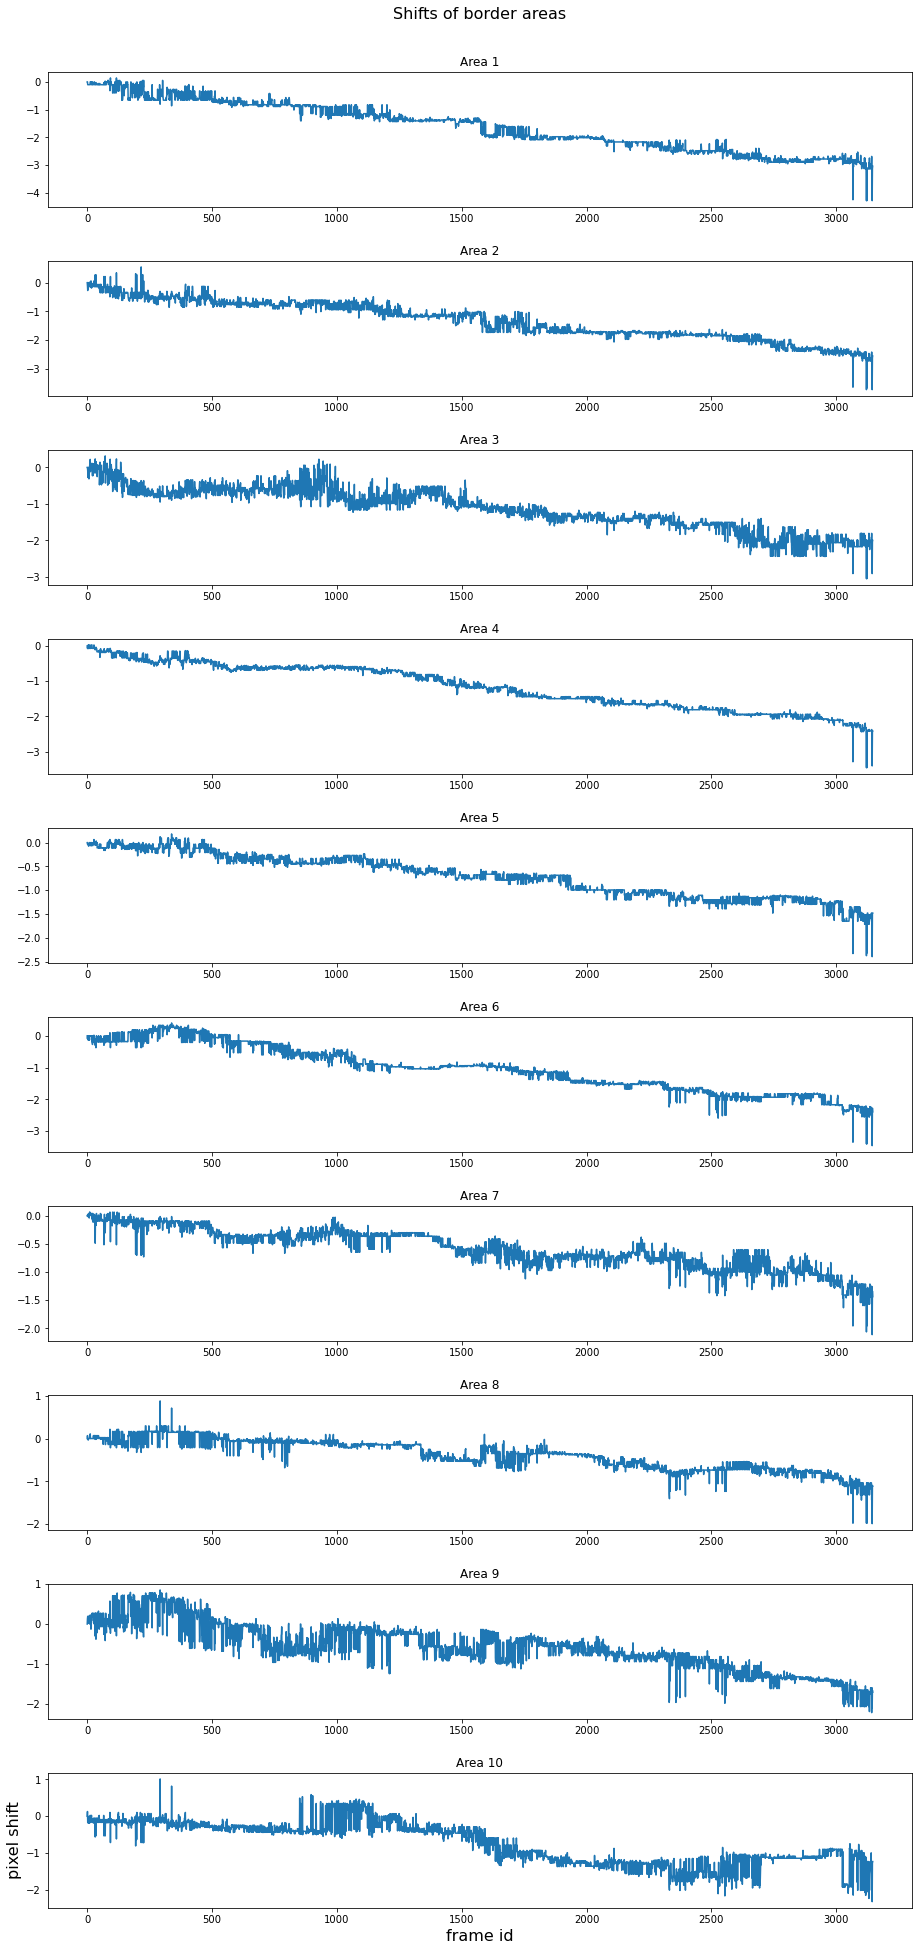

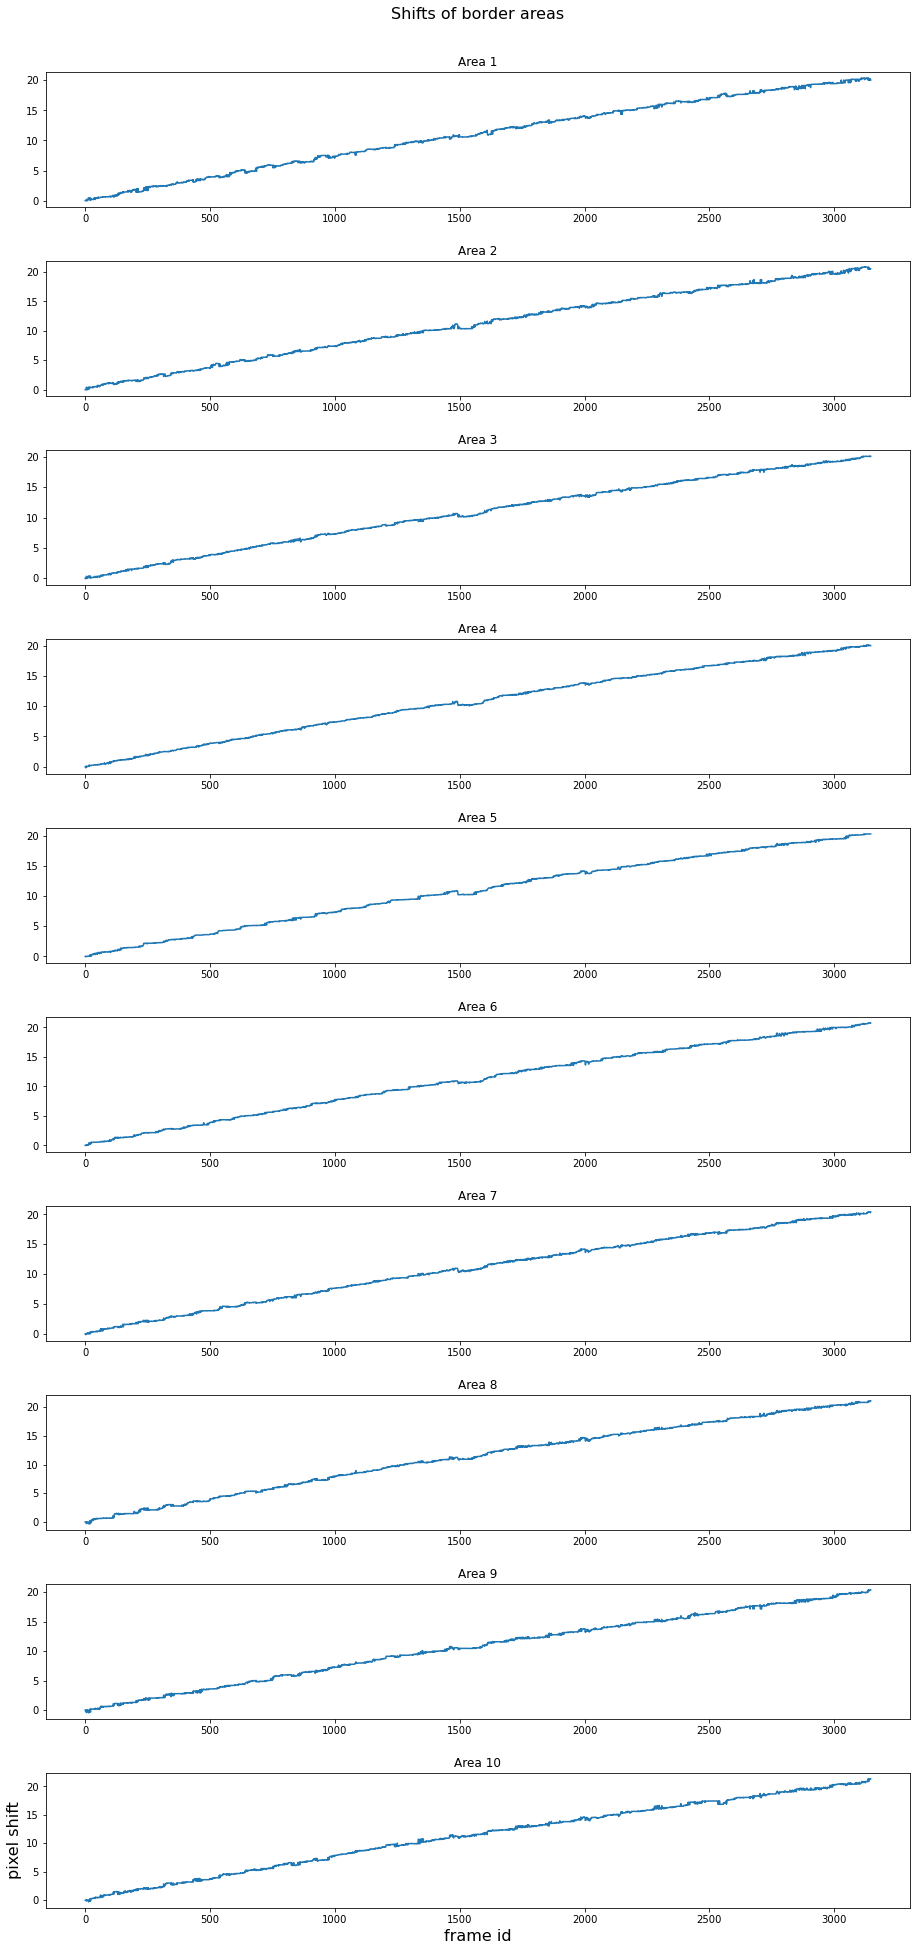

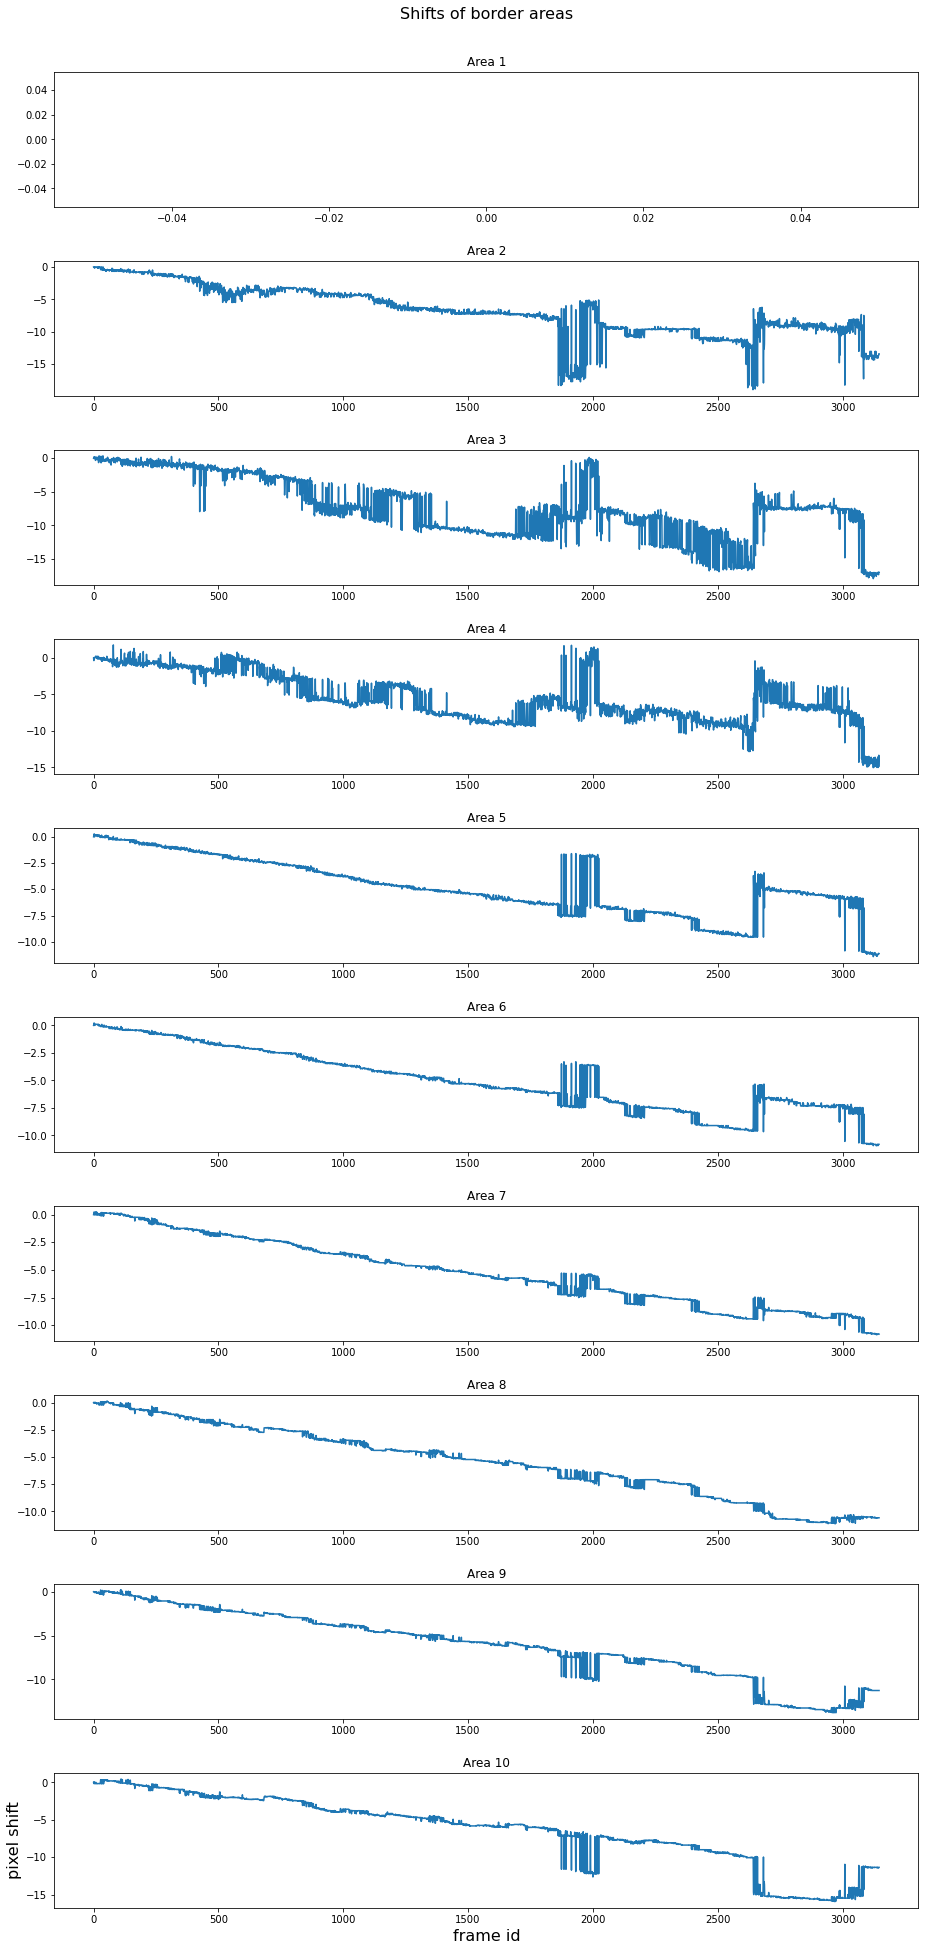

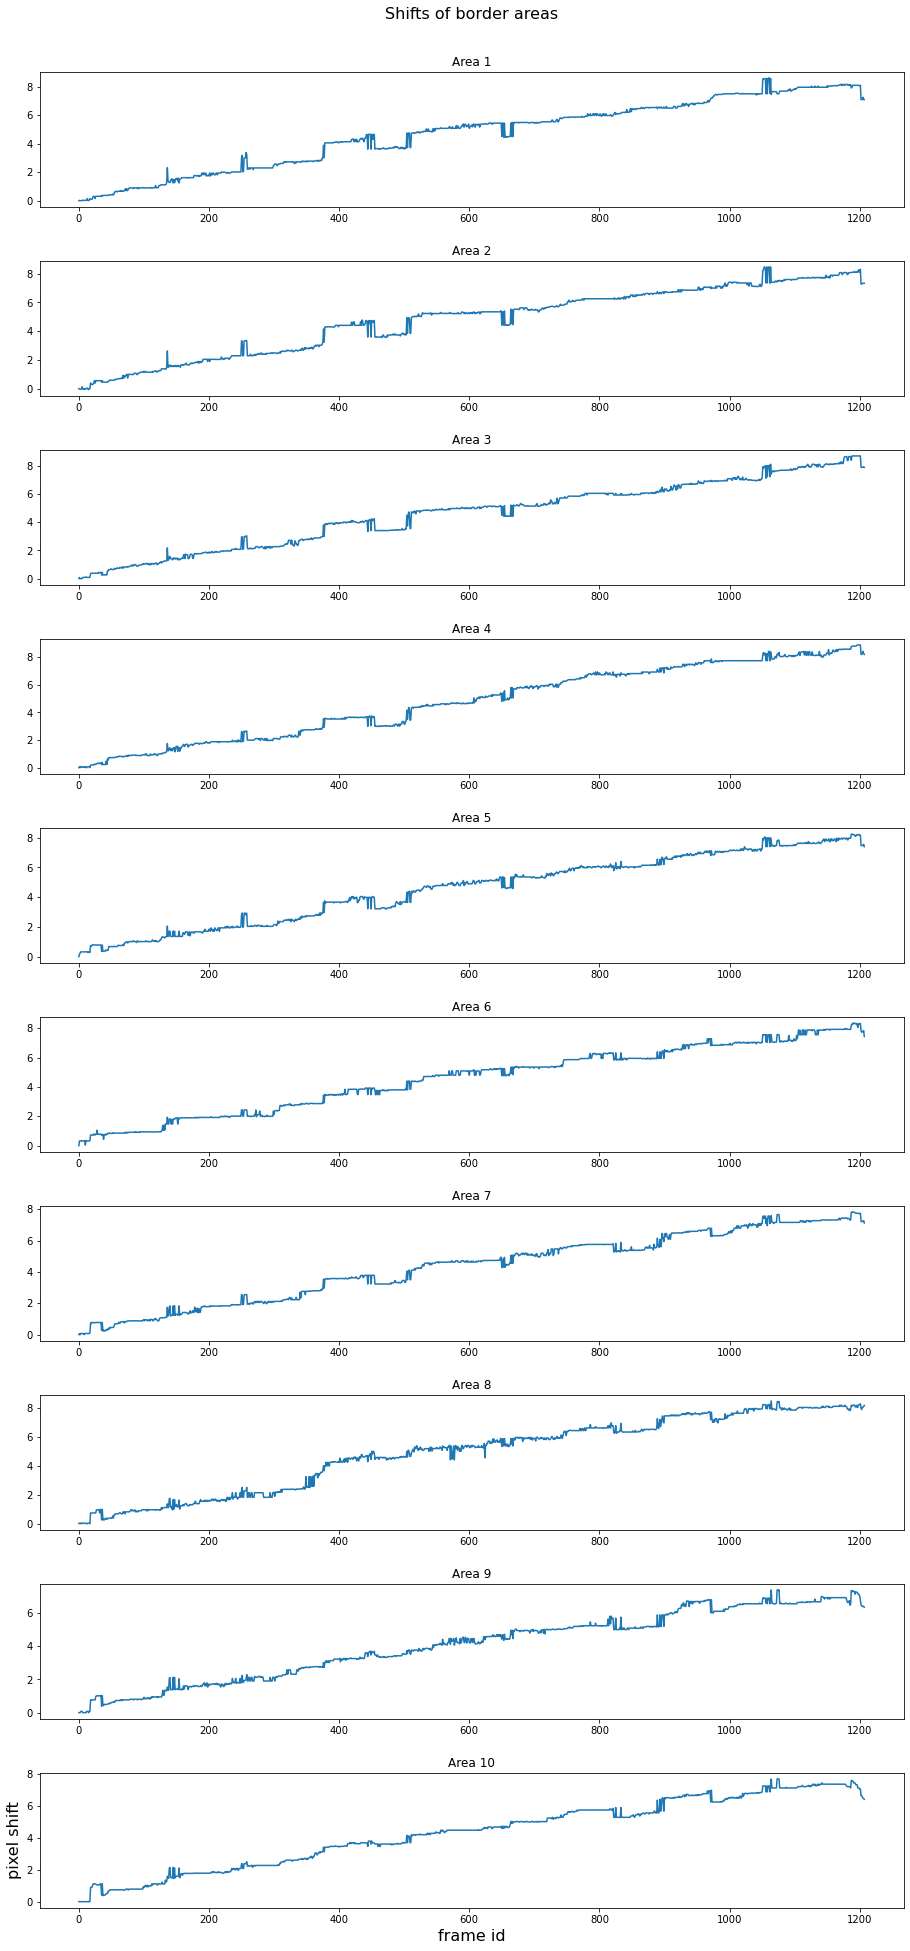

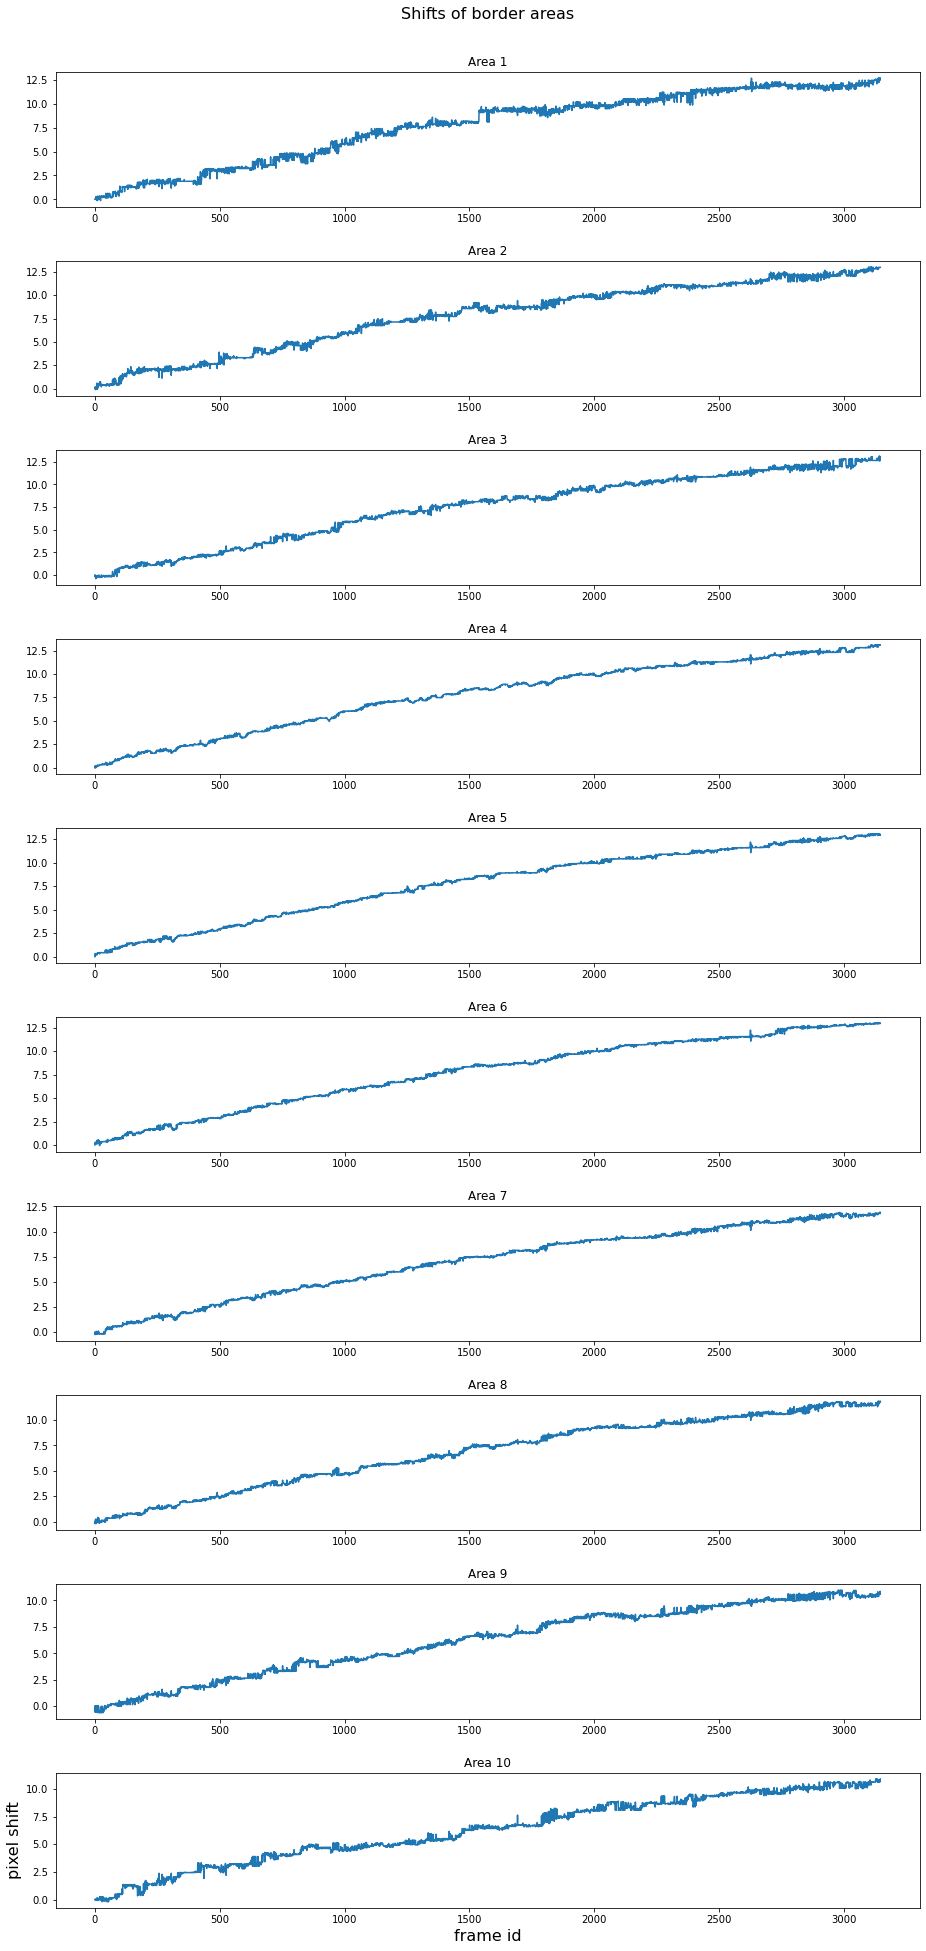

In [29]:
root_dir = 'extracted_signals_curare'
np_files=[file for file in os.listdir(root_dir) if file.endswith('.npy')]

#fig, ax = plt.subplots(15, figsize=(15,30))
#fig.suptitle('Shifts of border areas', fontsize=16)
    
for idx, file in enumerate(np_files):
    
    distances = np.load(os.path.join(root_dir, file))
    print('File: ', file, ' with shape: ', distances.shape)
    
    fig, ax = plt.subplots(10, figsize=(15,30))
    fig.suptitle('Shifts of border areas', fontsize=16)
    for i in range(10):
        ax[i].plot(np.arange(distances.shape[1]), distances[i,:])
        ax[i].set_title('Area '+str(i+1))
    '''
    # or plot for signal for each video
    ax[idx].plot(np.arange(distances.shape[1]), distances[0,:])
    ax[idx].set_title(file)
    '''  
    plt.xlabel('frame id', fontsize=16)
    plt.ylabel('pixel shift', fontsize=16)
    plt.subplots_adjust(left=0.1,
                        bottom=0.1, 
                        right=0.9, 
                        top=0.95, 
                        wspace=0.4, 
                        hspace=0.4)
    